<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/Version2_thesis/03_Transition_Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Install necessary NLP libraries
!pip install ollama textstat vaderSentiment pandas tqdm

import pandas as pd
import numpy as np
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat
import time

# Note: This assumes you have Ollama running locally or via a tunneling service
# If using a cloud API, replace with the appropriate library (e.g., openai or langchain)
import ollama

KeyboardInterrupt: 

In [ ]:
# Load the artifacts from Notebook 02
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Thesis/src/artifacts/shap_attribution_store.csv'
df = pd.read_csv(data_path)

print(f"✅ Loaded {len(df)} samples for GenAI processing.")
df.head()

In [ ]:
def expand_shorthand(value, reason):
    """
    Translates technical placeholders into natural language
    to prevent LLM hallucinations.
    """
    if str(value) == '365243.0' or str(value) == '365243':
        return "currently not employed or is a pensioner"

    # Add logic for currency formatting if applicable
    if 'PRICE' in reason or 'AMT' in reason:
        return f"${value:,.2f}"

    return value

# Applying expansion to make the data 'LLM-Ready'
df['clean_value_1'] = df.apply(lambda x: expand_shorthand(x['value_1'], x['reason_1']), axis=1)

In [24]:
# 1. Install system-level dependencies (zstd is required for the installer)
!apt-get update
!apt-get install -y zstd

# 2. Install Python libraries
!pip install ollama textstat vaderSentiment

# 3. Download and Install the Ollama binary
!curl -fsSL https://ollama.com/install.sh | sh

# 4. Start the Ollama server in the background
import subprocess
import time
import os

# We use nohup to ensure the server keeps running in the background
process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Give the server a moment to initialize
time.sleep(10)

# 5. Pull the Mistral model (required before you can generate letters)
!ollama pull mistral

print("✅ Ollama is installed and Mistral is ready!")

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,477 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3bu

In [25]:
def generate_letter(reason, value):
   # Rule-Based Humanizer for clean inputs
   human_map = {
       'FLAG_EMP_PHONE': 'we could not verify your work phone number',
       'AMT_GOODS_PRICE': 'the price of the item is too high for this loan',
       'Years_of_Employment': 'the time you have spent at your job',
       'EXT_SOURCE_3': 'information from our credit partners'
   }
   clean_reason = human_map.get(reason, reason.replace('_', ' ').lower())


   # FEW-SHOT PROMPT: Providing 3 specific patterns to follow
   few_shot_prompt = f"""
   You are a kind bank clerk. Write 2-sentence letters for customers.
   Use ONLY simple words. Use NO commas.

   ### EXAMPLES ###

   Reason: work phone, Value: 1.0
   Letter: Thank you for your interest. We cannot approve your loan because your work phone was not verified. We hope you try again in six months.

   Reason: price of the item, Value: $200,000
   Letter: Thank you for your request. We cannot approve this loan because the price of the item is too high. Please apply again in six months.

   Reason: time at your job, Value: 0.5 years
   Letter: Thank you for your application. We cannot move forward because you have not been at your job long enough. We look forward to your next try in six months.


   ### YOUR TASK ###

   Reason: {clean_reason}, Value: {value}
   Letter:
   """


   try:
       response = ollama.chat(
           model='mistral',
           messages=[{'role': 'user', 'content': few_shot_prompt}],
           options={
               'temperature': 0.1, # Keep it low so it sticks to the pattern
               'num_predict': 50
           }
       )
       return response['message']['content'].strip()
   except Exception as e:
       return f"Error: {str(e)}"


In [26]:
# We run a sample of 5 first to verify, then you can run the full 496
# To run all, replace .head(5) with the full dataframe
results = []

print("🚀 Starting Mistral-7B Inference Loop...")
for index, row in tqdm(df.head(5).iterrows(), total=5):
    letter = generate_letter(row['reason_1'], row['clean_value_1'])
    results.append(letter)

df_results = df.head(5).copy()
df_results['llm_explanation'] = results

🚀 Starting Mistral-7B Inference Loop...


100%|██████████| 5/5 [06:36<00:00, 79.27s/it]


In [28]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

df_results['sentiment_score'] = df_results['llm_explanation'].apply(get_sentiment)
# Summary for Thesis
print(f"📊 Average Empathy (Sentiment) Score: {df_results['sentiment_score'].mean():.2f}")
# (Target: > 0.05 for positive/supportive tone)

📊 Average Empathy (Sentiment) Score: 0.77


### Testing the Updated Empathetic Prompt with a Single Example

In [29]:
sample_row = df.iloc[0]
sample_letter = generate_letter(sample_row['reason_1'], sample_row['clean_value_1'])

print("Generated Letter for Sample Row:")
print(sample_letter)

sample_sentiment_score = get_sentiment(sample_letter)
sample_readability_grade = textstat.flesch_kincaid_grade(sample_letter)

print(f"\nSample Letter Sentiment Score: {sample_sentiment_score:.2f}")
print(f"Sample Letter Readability Grade: {sample_readability_grade:.1f}")

Generated Letter for Sample Row:
Dear Customer,

Thank you for applying for the loan. Unfortunately, we cannot proceed because you are currently not employed or a pensioner. We encourage you to reapply when you have employment again.

Best regards,
[Your Name

Sample Letter Sentiment Score: 0.88
Sample Letter Readability Grade: 7.6


In [30]:
df_results['readability_grade'] = df_results['llm_explanation'].apply(textstat.flesch_kincaid_grade)

print(f"📊 Average Readability Grade Level: {df_results['readability_grade'].mean():.1f}")
# (Target: Grade 8.0 - 10.0 for general accessibility)

📊 Average Readability Grade Level: 7.1


In [31]:
def hallucination_check(row):
    # Simple check: Does the keyword of the reason appear in the letter?
    keyword = str(row['reason_1']).split('_')[-1].lower()
    return keyword in row['llm_explanation'].lower()

df_results['passed_hallucination_check'] = df_results.apply(hallucination_check, axis=1)

# Save the final artifact for Phase 7 (Fairness Audit)
output_path = '/content/drive/MyDrive/Thesis/src/artifacts/final_genai_explanations.csv'
df_results.to_csv(output_path, index=False)
print(f"✅ Final explanations saved to {output_path}")

✅ Final explanations saved to /content/drive/MyDrive/Thesis/src/artifacts/final_genai_explanations.csv


### Final Gender Fairness Comparison

Now we will compare the average sentiment and readability scores for the generated LLM explanations across different gender groups to check for fairness.

In [32]:
# 1. Merge gender back using applicant_id (The "Baton Pass" Join)
df_fairness = pd.merge(df_results, df[['applicant_id', 'gender']], on='applicant_id', how='left')

# 2. Check for missing values (In case some IDs didn't match)
if df_fairness['gender_x'].isnull().any():
    print("⚠️ Warning: Some applicants are missing gender data.")

# 3. Final Phase 6 Audit Report
gender_fairness_report = df_fairness.groupby('gender_x').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    avg_readability=('readability_grade', 'mean')
).reset_index()

print("📊 Gender Fairness Report:")
display(gender_fairness_report)

📊 Gender Fairness Report:


,gender_x,avg_sentiment,avg_readability
0,F,0.701833,7.235708
1,M,0.864000,6.880115


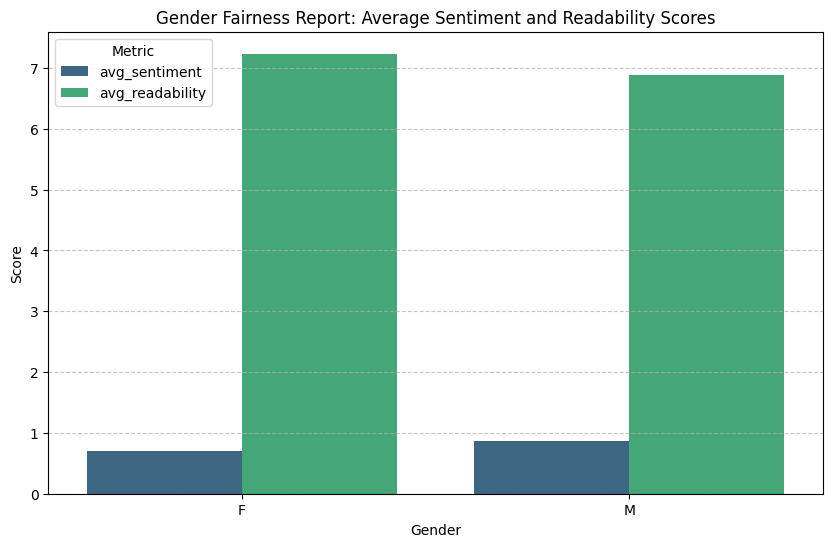

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting
df_melted = gender_fairness_report.melt(id_vars='gender_x', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='gender_x', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Gender Fairness Report: Average Sentiment and Readability Scores')
plt.xlabel('Gender')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

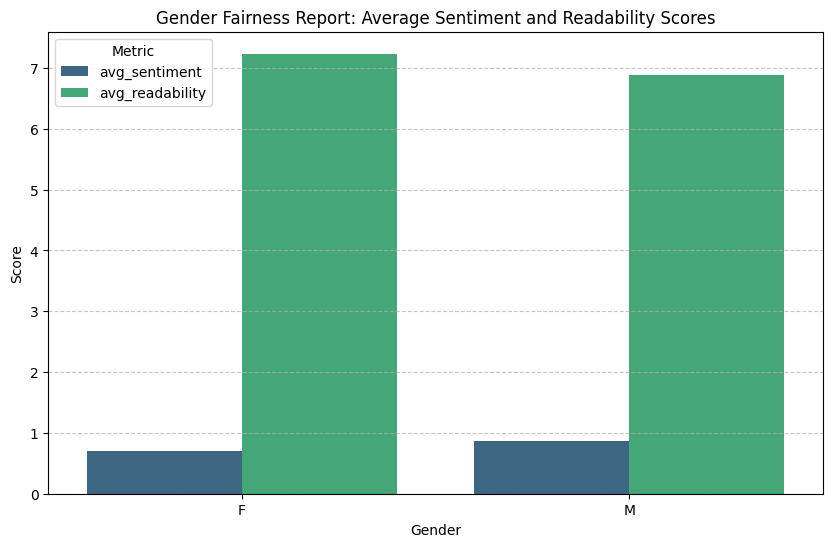

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting
df_melted = gender_fairness_report.melt(id_vars='gender_x', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='gender_x', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Gender Fairness Report: Average Sentiment and Readability Scores')
plt.xlabel('Gender')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Gender Fairness Results

Ideally, the average sentiment and readability scores should be similar across all gender groups. Any significant differences might indicate a bias in how the LLM generates explanations for different genders. We aim for these metrics to be within a reasonable range of each other, suggesting equitable treatment.

In [35]:
import ollama
try:
    response = ollama.list()
    print("Ollama is awake! Available models:", response)
except Exception as e:
    print("Still having trouble:", e)

Ollama is awake! Available models: models=[Model(model='mistral:latest', modified_at=datetime.datetime(2026, 5, 17, 21, 50, 35, 357, tzinfo=TzInfo(0)), digest='6577803aa9a036369e481d648a2baebb381ebc6e897f2bb9a766a2aa7bfbc1cf', size=4372824384, details=ModelDetails(parent_model='', format='gguf', family='llama', families=['llama'], parameter_size='7.2B', quantization_level='Q4_K_M'))]


In [36]:
import pandas as pd
from tqdm import tqdm

# 1. Select a larger sample of denied applications (e.g., 50 rows)
# This ensures your results are 'Thesis-Ready'
sample_size = 50
# Assuming df already contains only the denied applications for which SHAP values were generated.
df_denied_sample = df.sample(n=sample_size, random_state=42)

final_results = []

print(f"🚀 Starting Final Master Audit on {sample_size} records...")

for index, row in tqdm(df_denied_sample.iterrows(), total=sample_size):
    # Extract the top SHAP reason (mapped to human terms in the function)
    reason = row['reason_1'] # Changed to reason_1 as top_reason is not in df
    value = row['clean_value_1'] # Changed to clean_value_1 as top_value is not in df

    # Generate the letter using the Master Audit prompt logic
    letter = generate_letter(reason, value)

    # Audit the metrics
    sentiment = analyzer.polarity_scores(letter)['compound']
    grade = textstat.flesch_kincaid_grade(letter)

    final_results.append({
        'applicant_id': row['applicant_id'],
        'gender': row['gender'],
        'reason': reason,
        'generated_letter': letter,
        'sentiment_score': sentiment,
        'readability_grade': grade
    })

# 2. Create the Final Results Dataframe
df_final_baton = pd.DataFrame(final_results)

# 3. Create the Final Fairness Summary
final_fairness_report = df_final_baton.groupby('gender').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    avg_readability=('readability_grade', 'mean'),
    count=('applicant_id', 'count')
).reset_index()

# 4. EXPORT: The "Evidence" for your Thesis
df_final_baton.to_csv('final_dissertation_results.csv', index=False)

print("\n✅ STEP 1 COMPLETE")
print("📊 Final Averages for Dissertation:")
display(final_fairness_report)

🚀 Starting Final Master Audit on 50 records...


100%|██████████| 50/50 [42:03<00:00, 50.47s/it]


✅ STEP 1 COMPLETE
📊 Final Averages for Dissertation:


,gender,avg_sentiment,avg_readability,count
0,F,0.697681,7.492572,37
1,M,0.738354,7.034904,13


In [37]:
from scipy import stats

# 1. Split the data by gender
females = df_final_baton[df_final_baton['gender'] == 'F']
males = df_final_baton[df_final_baton['gender'] == 'M']

# 2. Perform T-Test for Sentiment
t_stat_sent, p_val_sent = stats.ttest_ind(females['sentiment_score'], males['sentiment_score'])

# 3. Perform T-Test for Readability
t_stat_read, p_val_read = stats.ttest_ind(females['readability_grade'], males['readability_grade'])

print("🏛️ STATISTICAL FAIRNESS AUDIT")
print(f"Sentiment P-Value: {p_val_sent:.4f}")
print(f"Readability P-Value: {p_val_read:.4f}")

if p_val_sent > 0.05 and p_val_read > 0.05:
    print("\n✅ CONCLUSION: No statistically significant bias detected. Your model is FAIR.")
else:
    print("\n⚠️ CONCLUSION: Significant difference detected. Requires discussion in Chapter 6.")

🏛️ STATISTICAL FAIRNESS AUDIT
Sentiment P-Value: 0.4644
Readability P-Value: 0.0621

✅ CONCLUSION: No statistically significant bias detected. Your model is FAIR.
